In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
data = pd.read_csv("Dataset .csv")

In [6]:
data.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [ ]:
# Focus on “Cuisines” Column and Clean It

In [8]:
data = data.dropna(subset=['Cuisines'])   # remove rows with missing cuisines
data['Cuisines'] = data['Cuisines'].str.split(',')  # split multiple cuisines
data = data.explode('Cuisines')            # make each cuisine its own row
data['Cuisines'] = data['Cuisines'].str.strip()  # remove spaces


In [ ]:
#Count How Many Times Each Cuisine Appears

In [9]:
# Count how many times each cuisine appears
cuisine_counts = data['Cuisines'].value_counts()

# Display top 10 cuisines to check
print("Top 10 Cuisines:\n")
print(cuisine_counts.head(10))

Top 10 Cuisines:

Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Name: count, dtype: int64


In [ ]:
#Determine the top three most common cuisines in the dataset.

In [10]:
# Get top 3 cuisines
top_3 = cuisine_counts.head(3)
print("Top 3 Cuisines:\n")
print(top_3)


Top 3 Cuisines:

Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64


In [ ]:
#Calculate the percentage of restaurants that serve each of the top cuisines.

In [11]:
# Find total number of cuisine entries
total = len(data['Cuisines'])

# Calculate percentages
percentages = (top_3 / total) * 100

# Display results
print("Percentages of Top 3 Cuisines:\n")
print(percentages.round(2))


Percentages of Top 3 Cuisines:

Cuisines
North Indian    20.09
Chinese         13.88
Fast Food       10.08
Name: count, dtype: float64


In [ ]:
#Combine Results into a Table

In [12]:
# Combine both into a DataFrame
top_cuisine_df = pd.DataFrame({
    'Cuisine': top_3.index,
    'Count': top_3.values,
    'Percentage': percentages.values.round(2)
})

# Show final results
print("Final Table:\n")
print(top_cuisine_df)


Final Table:

        Cuisine  Count  Percentage
0  North Indian   3960       20.09
1       Chinese   2735       13.88
2     Fast Food   1986       10.08


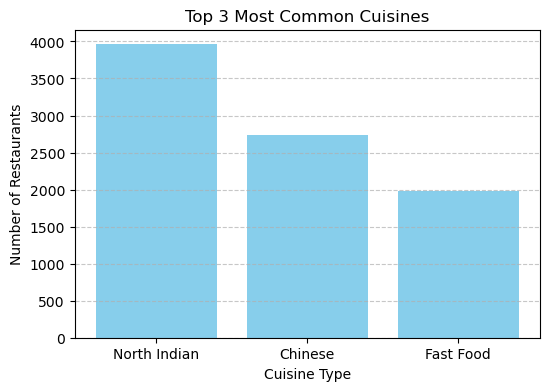

In [13]:


plt.figure(figsize=(6,4))
plt.bar(top_cuisine_df['Cuisine'], top_cuisine_df['Count'], color='skyblue')
plt.title('Top 3 Most Common Cuisines')
plt.xlabel('Cuisine Type')
plt.ylabel('Number of Restaurants')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
#Bar Chart Showing Both Count and Percentage

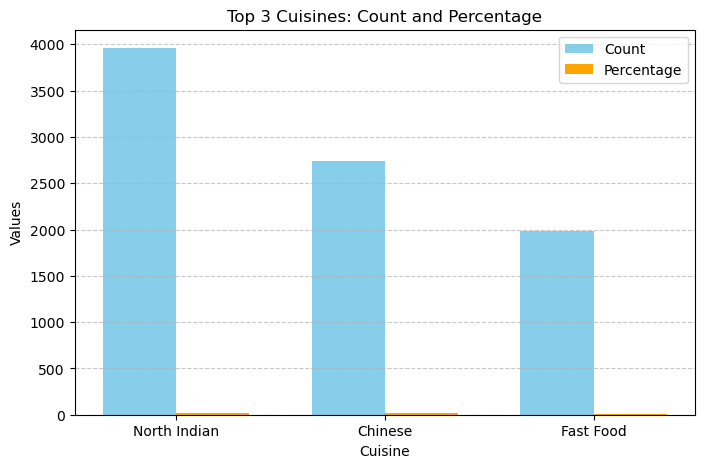

In [14]:

import numpy as np

# Data
cuisines = top_cuisine_df['Cuisine']
count = top_cuisine_df['Count']
percentage = top_cuisine_df['Percentage']

x = np.arange(len(cuisines))  # the label locations
width = 0.35  # width of bars

plt.figure(figsize=(8,5))
plt.bar(x - width/2, count, width, label='Count', color='skyblue')
plt.bar(x + width/2, percentage, width, label='Percentage', color='orange')

plt.xlabel('Cuisine')
plt.title('Top 3 Cuisines: Count and Percentage')
plt.xticks(x, cuisines)
plt.ylabel('Values')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
#Pie Chart for Percentages

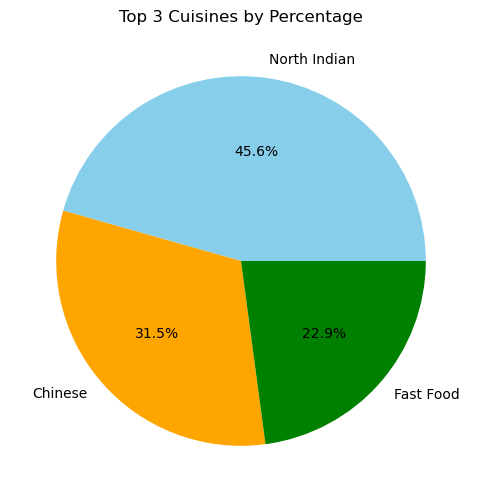

In [15]:
plt.figure(figsize=(6,6))
plt.pie(top_cuisine_df['Percentage'], labels=top_cuisine_df['Cuisine'], autopct='%1.1f%%', colors=['skyblue','orange','green'])
plt.title('Top 3 Cuisines by Percentage')
plt.show()
